In [ ]:
Machine Learning
Dataset: Default of Credit Card Clients
Reason: Strong tabular ML dataset for classification, feature engineering, and imbalance handling
url: https://archive.ics.uci.edu/ml/datasets/default+of+credit+card+clients
Platform: Google Colab
Concepts covered:
Logistic Regression: a strong baseline for binary classification.
Decision Tree: easy to interpret and useful for non-linear splits.
Random Forest: usually stronger than a single tree because it averages many trees.
Gradient Boosting: often performs well on tabular data by building trees sequentially.

In [1]:
# Install libraries and dependencies
!pip -q install ucimlrepo pyspark tensorflow scikit-learn seaborn matplotlib pandas openpyxl

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from scipy.stats import beta

print ("libraries ready")

libraries ready


In [2]:
plt.style.use("seaborn-v0_8")
sns.set_theme(style="whitegrid")
np.random.seed(42)
tf.random.set_seed(42)
print("Set up visualization boards")


Set up visualization boards


In [3]:
# Load dataset

credit = fetch_ucirepo(id=350)
X = credit.data.features
y = credit.data.targets

df = pd.concat([X, y], axis=1)

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

target_col = y.columns[0]

# Optional: convert target to 0/1 if needed
if df[target_col].dtype == "object":
    df[target_col] = df[target_col].map({"No": 0, "Yes": 1})
print("dataset ready")

Dataset shape: (30000, 24)

First 5 rows:
       X1  X2  X3  X4  X5  X6  X7  X8  X9  X10  ...    X15    X16    X17  \
0   20000   2   2   1  24   2   2  -1  -1   -2  ...      0      0      0   
1  120000   2   2   2  26  -1   2   0   0    0  ...   3272   3455   3261   
2   90000   2   2   2  34   0   0   0   0    0  ...  14331  14948  15549   
3   50000   2   2   1  37   0   0   0   0    0  ...  28314  28959  29547   
4   50000   1   2   1  57  -1   0  -1   0    0  ...  20940  19146  19131   

    X18    X19    X20   X21   X22   X23  Y  
0     0    689      0     0     0     0  1  
1     0   1000   1000  1000     0  2000  1  
2  1518   1500   1000  1000  1000  5000  0  
3  2000   2019   1200  1100  1069  1000  0  
4  2000  36681  10000  9000   689   679  0  

[5 rows x 24 columns]
dataset ready


In [4]:
# Basic statistical analysis
print("\nSummary statistics:")
print(df.describe())

print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False).head(10))

print("\nTarget distribution:")
print(df[target_col].value_counts())



Summary statistics:
                   X1            X2            X3            X4            X5  \
count    30000.000000  30000.000000  30000.000000  30000.000000  30000.000000   
mean    167484.322667      1.603733      1.853133      1.551867     35.485500   
std     129747.661567      0.489129      0.790349      0.521970      9.217904   
min      10000.000000      1.000000      0.000000      0.000000     21.000000   
25%      50000.000000      1.000000      1.000000      1.000000     28.000000   
50%     140000.000000      2.000000      2.000000      2.000000     34.000000   
75%     240000.000000      2.000000      2.000000      2.000000     41.000000   
max    1000000.000000      2.000000      6.000000      3.000000     79.000000   

                 X6            X7            X8            X9           X10  \
count  30000.000000  30000.000000  30000.000000  30000.000000  30000.000000   
mean      -0.016700     -0.133767     -0.166200     -0.220667     -0.266200   
std        1

Available columns: ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23', 'Y']


/tmp/ipykernel_12516/2085746753.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_col, y=feature_col, data=df, ax=axes[0, 1], palette="Set2")
/tmp/ipykernel_12516/2085746753.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_col, data=df, ax=axes[1, 1], palette="Set3")


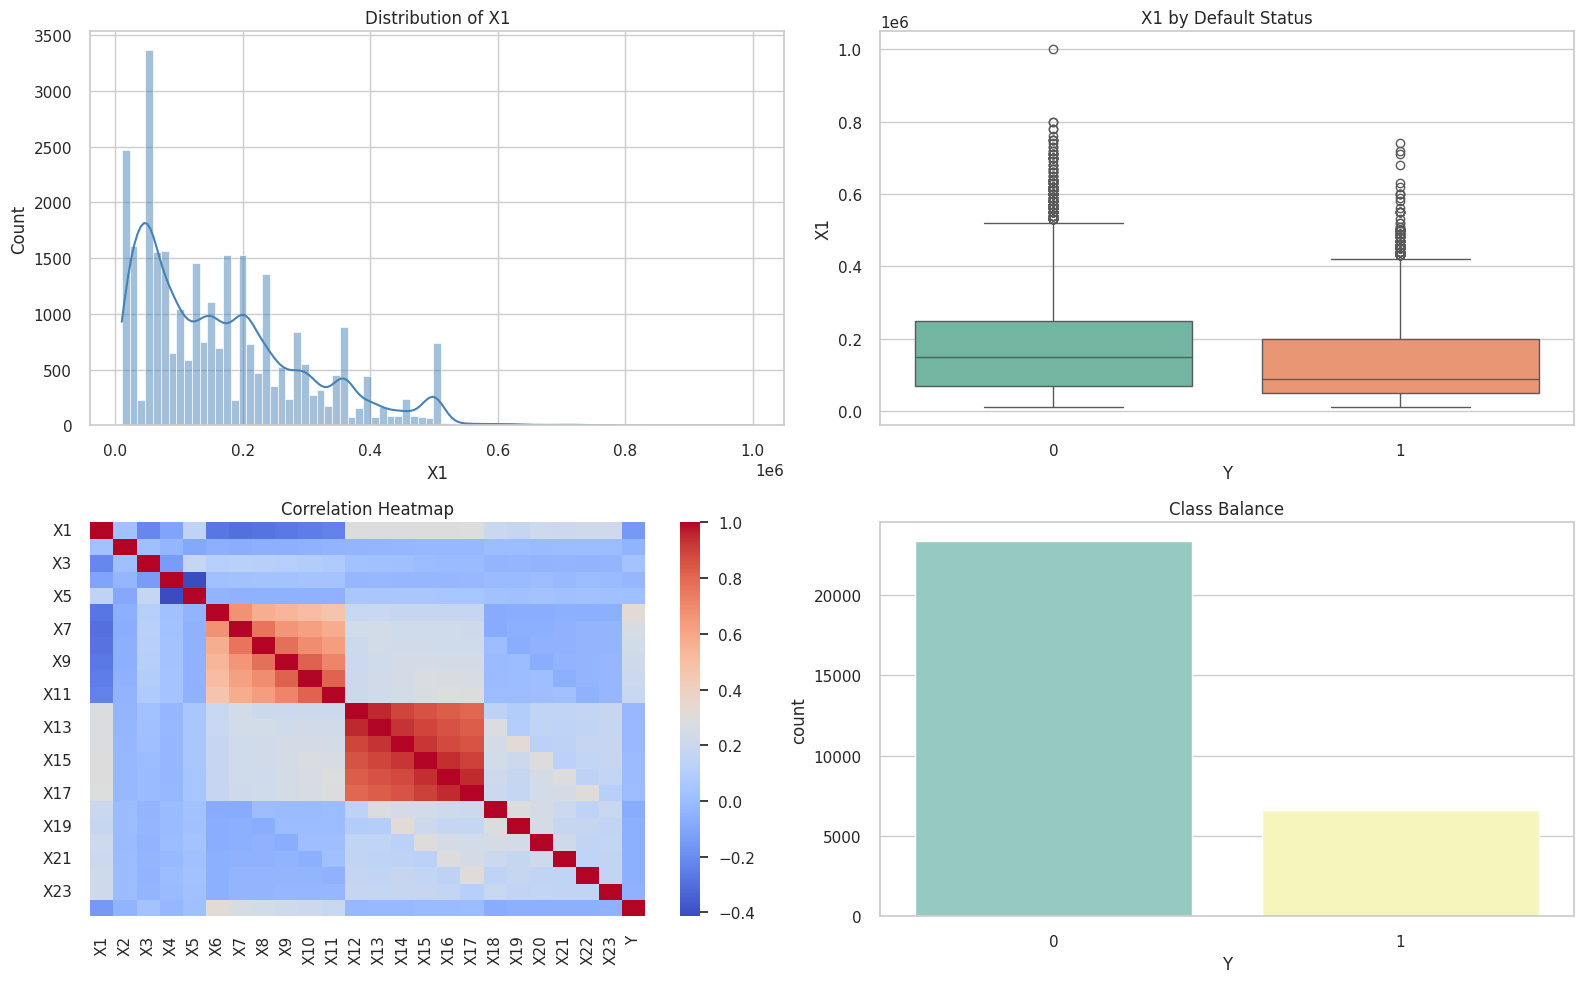

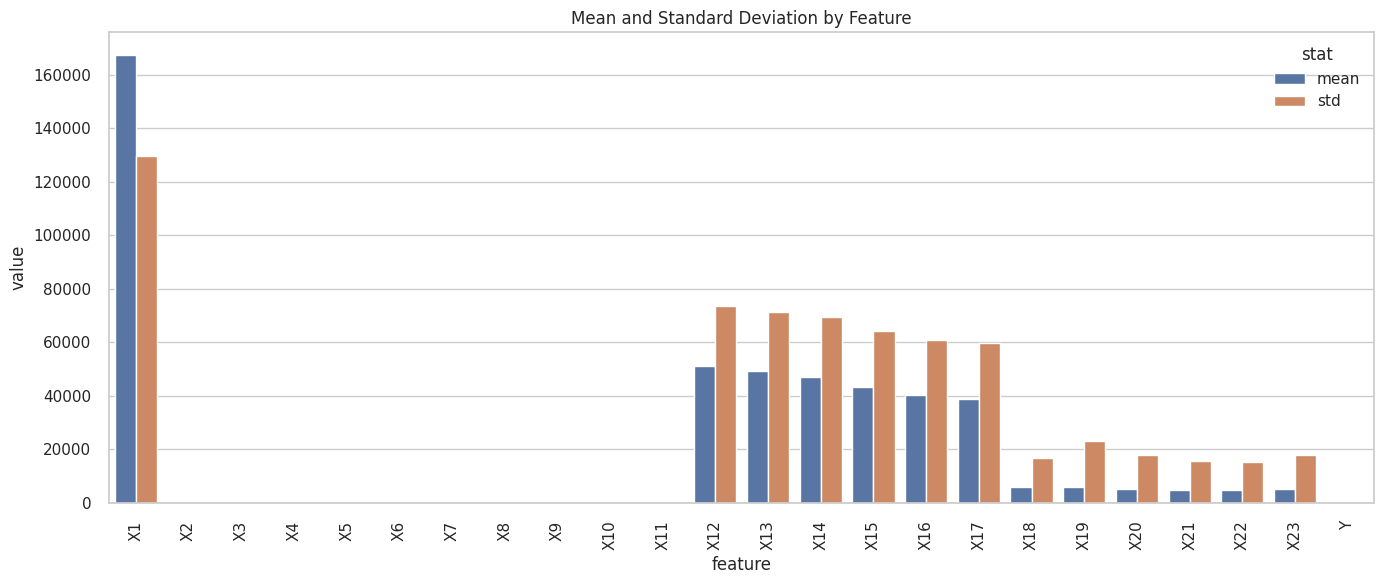

In [9]:
# Visualizations

print("Available columns:", df.columns.tolist())

# Choose a numeric feature safely
numeric_cols = df.select_dtypes(include="number").columns.tolist()
feature_col = "LIMIT_BAL" if "LIMIT_BAL" in df.columns else numeric_cols[0]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.histplot(df[feature_col], kde=True, ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title(f"Distribution of {feature_col}")

sns.boxplot(x=target_col, y=feature_col, data=df, ax=axes[0, 1], palette="Set2")
axes[0, 1].set_title(f"{feature_col} by Default Status")

sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", ax=axes[1, 0])
axes[1, 0].set_title("Correlation Heatmap")

sns.countplot(x=target_col, data=df, ax=axes[1, 1], palette="Set3")
axes[1, 1].set_title("Class Balance")

plt.tight_layout()
plt.show()

# Feature statistics plot
summary_stats = df.describe().T[["mean", "std"]].reset_index().rename(columns={"index": "feature"})
summary_long = summary_stats.melt(id_vars="feature", value_vars=["mean", "std"], var_name="stat", value_name="value")

plt.figure(figsize=(14, 6))
sns.barplot(data=summary_long, x="feature", y="value", hue="stat")
plt.xticks(rotation=90)
plt.title("Mean and Standard Deviation by Feature")
plt.tight_layout()
plt.show()

In [10]:
# Prepare features
feature_cols = [c for c in df.columns if c != target_col]
X = df[feature_cols].copy()
y = df[target_col].astype(int).copy()
print("features ready")


features ready



Logistic Regression
Accuracy: 0.8076666666666666
ROC AUC: 0.7076355036089734
[[4528  145]
 [1009  318]]
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4673
           1       0.69      0.24      0.36      1327

    accuracy                           0.81      6000
   macro avg       0.75      0.60      0.62      6000
weighted avg       0.79      0.81      0.77      6000


Decision Tree
Accuracy: 0.8163333333333334
ROC AUC: 0.7449846969983088
[[4421  252]
 [ 850  477]]
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.65      0.36      0.46      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.68      6000
weighted avg       0.80      0.82      0.80      6000


Random Forest
Accuracy: 0.8123333333333334
ROC AUC: 0.7544770895221165
[[4390  283]
 [ 843  484]]
              precision    recall  f1-score

/tmp/ipykernel_12516/116469307.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(accs.keys()), y=list(accs.values()), palette="viridis")


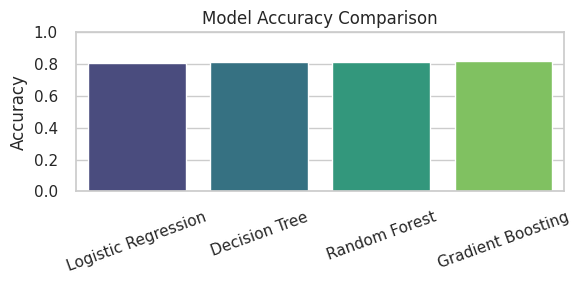

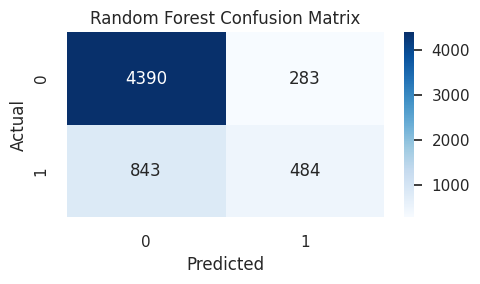

In [13]:
# Supervised Learning - Classification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

logit = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, random_state=42))
])
logit.fit(X_train, y_train)
pred_logit = logit.predict(X_test)
prob_logit = logit.predict_proba(X_test)[:, 1]

tree = DecisionTreeClassifier(random_state=42, max_depth=6)
tree.fit(X_train, y_train)
pred_tree = tree.predict(X_test)
prob_tree = tree.predict_proba(X_test)[:, 1]

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
prob_rf = rf.predict_proba(X_test)[:, 1]

gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
pred_gb = gb.predict(X_test)
prob_gb = gb.predict_proba(X_test)[:, 1]

def show_metrics(name, y_true, pred, prob):
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_true, pred))
    print("ROC AUC:", roc_auc_score(y_true, prob))
    print(confusion_matrix(y_true, pred))
    print(classification_report(y_true, pred))

show_metrics("Logistic Regression", y_test, pred_logit, prob_logit)
show_metrics("Decision Tree", y_test, pred_tree, prob_tree)
show_metrics("Random Forest", y_test, pred_rf, prob_rf)
show_metrics("Gradient Boosting", y_test, pred_gb, prob_gb)

accs = {
    "Logistic Regression": accuracy_score(y_test, pred_logit),
    "Decision Tree": accuracy_score(y_test, pred_tree),
    "Random Forest": accuracy_score(y_test, pred_rf),
    "Gradient Boosting": accuracy_score(y_test, pred_gb),
}

plt.figure(figsize=(6, 3))
sns.barplot(x=list(accs.keys()), y=list(accs.values()), palette="viridis")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 3))
sns.heatmap(confusion_matrix(y_test, pred_rf), annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()



Regression section (illustrative only)
Prediction sample: [0.24941691 0.17441278 0.21987073 0.25293953 0.20800538]


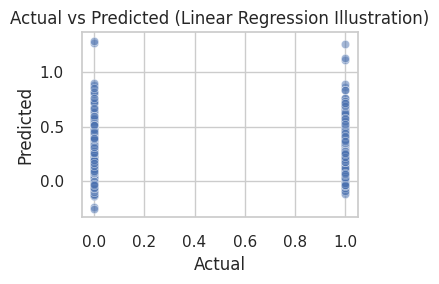

In [15]:
# Regression
# This dataset is classification-first; regression is illustrative.

y_numeric = y.astype(float)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_numeric, test_size=0.2, random_state=42
)

reg = Pipeline([
    ("scaler", StandardScaler()),
    ("reg", LinearRegression())
])
reg.fit(X_train_r, y_train_r)
reg_pred = reg.predict(X_test_r)

print("\nRegression section (illustrative only)")
print("Prediction sample:", reg_pred[:5])

plt.figure(figsize=(4, 3))
sns.scatterplot(x=y_test_r, y=reg_pred, alpha=0.5)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (Linear Regression Illustration)")
plt.tight_layout()
plt.show()


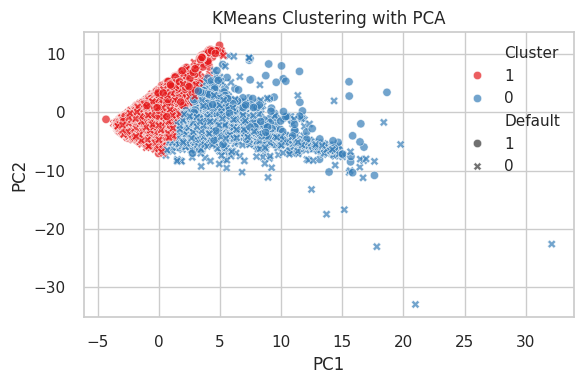

In [19]:
# Unsupervised Learning - Clustering

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

cluster_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cluster": clusters.astype(str),
    "Default": y.astype(str).values
})

plt.figure(figsize=(6, 4))
sns.scatterplot(data=cluster_df, x="PC1", y="PC2", hue="Cluster", style="Default", palette="Set1", alpha=0.7)
plt.title("KMeans Clustering with PCA")
plt.tight_layout()
plt.show()


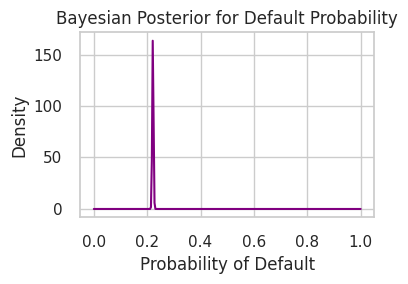


Posterior mean probability of default: 0.22121858542763817


In [21]:
# Bayesian modeling section

# Simple Bayesian estimate for default probability.
successes = int(y.sum())
failures = int((1 - y).sum())
post_a = 1 + successes
post_b = 1 + failures

x_vals = np.linspace(0, 1, 300)
posterior = beta.pdf(x_vals, post_a, post_b)

plt.figure(figsize=(4, 3))
plt.plot(x_vals, posterior, color="purple")
plt.title("Bayesian Posterior for Default Probability")
plt.xlabel("Probability of Default")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

print("\nPosterior mean probability of default:",
      post_a / (post_a + post_b))



TensorFlow test accuracy: 0.8106666803359985


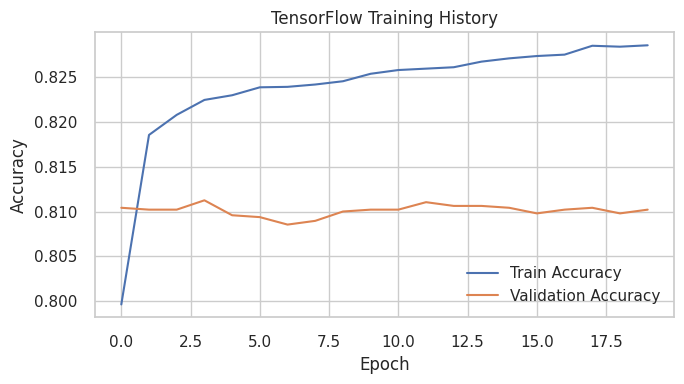

In [23]:
# TensorFlow

X_train_tf, X_test_tf, y_train_tf, y_test_tf = train_test_split(
    X_scaled, y.values, test_size=0.2, random_state=42, stratify=y
)

tf_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_tf.shape[1],)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

tf_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
history = tf_model.fit(
    X_train_tf, y_train_tf,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    verbose=0
)

tf_loss, tf_acc = tf_model.evaluate(X_test_tf, y_test_tf, verbose=0)
print("\nTensorFlow test accuracy:", tf_acc)

plt.figure(figsize=(7, 4))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("TensorFlow Training History")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()


In [24]:
# PySpark

from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StandardScaler as SparkStandardScaler
from pyspark.ml.classification import LogisticRegression as SparkLogisticRegression
from pyspark.ml.classification import DecisionTreeClassifier as SparkDecisionTreeClassifier
from pyspark.ml.classification import RandomForestClassifier as SparkRandomForestClassifier
from pyspark.ml.classification import GBTClassifier
from pyspark.ml import Pipeline as SparkPipeline
from pyspark.ml.evaluation import BinaryClassificationEvaluator

spark = SparkSession.builder.master("local[*]").appName("CreditCardDefault").getOrCreate()
spark_df = spark.createDataFrame(df)

print("\nPySpark shape:", (spark_df.count(), len(spark_df.columns)))

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features_raw")
scaler_sp = SparkStandardScaler(inputCol="features_raw", outputCol="features", withStd=True, withMean=True)

spark_train, spark_test = spark_df.randomSplit([0.8, 0.2], seed=42)

spark_lr = SparkLogisticRegression(featuresCol="features", labelCol=target_col, maxIter=50)
spark_dt = SparkDecisionTreeClassifier(featuresCol="features", labelCol=target_col)
spark_rf = SparkRandomForestClassifier(featuresCol="features", labelCol=target_col, numTrees=100)
spark_gbt = GBTClassifier(featuresCol="features", labelCol=target_col, maxIter=50)

pipeline_lr = SparkPipeline(stages=[assembler, scaler_sp, spark_lr])
pipeline_dt = SparkPipeline(stages=[assembler, scaler_sp, spark_dt])
pipeline_rf = SparkPipeline(stages=[assembler, scaler_sp, spark_rf])
pipeline_gbt = SparkPipeline(stages=[assembler, scaler_sp, spark_gbt])

m_lr = pipeline_lr.fit(spark_train)
m_dt = pipeline_dt.fit(spark_train)
m_rf = pipeline_rf.fit(spark_train)
m_gbt = pipeline_gbt.fit(spark_train)

p_lr = m_lr.transform(spark_test)
p_dt = m_dt.transform(spark_test)
p_rf = m_rf.transform(spark_test)
p_gbt = m_gbt.transform(spark_test)

evaluator = BinaryClassificationEvaluator(labelCol=target_col, rawPredictionCol="rawPrediction", metricName="areaUnderROC")

print("\nPySpark AUC scores:")
print("Logistic Regression:", evaluator.evaluate(p_lr))
print("Decision Tree:", evaluator.evaluate(p_dt))
print("Random Forest:", evaluator.evaluate(p_rf))
print("Gradient Boosting:", evaluator.evaluate(p_gbt))

spark.stop()




PySpark shape: (30000, 24)

PySpark AUC scores:
Logistic Regression: 0.7277285666866162
Decision Tree: 0.32070342474428026
Random Forest: 0.7742450919283046
Gradient Boosting: 0.7772438643412866


In [25]:
# 13) End
print("\nCompleted credit card default dataset workflow.")



Completed credit card default dataset workflow.
